# Evaluation of a structure of samples from models on 60km -> 2.2km-4x over Birmingham

In [ ]:
%reload_ext autoreload

%autoreload 2

%reload_ext dotenv
%dotenv

import functools
import math
import string

import IPython
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from mlde_analysis.data import prep_eval_data
from mlde_analysis.psd import plot_psd, pysteps_rapsd

Pysteps configuration file found at: /home/users/vf20964/code/mlde-analysis/.pixi/envs/default/lib/python3.12/site-packages/pysteps/pystepsrc



/home/users/vf20964/code/mlde-analysis/.pixi/envs/default/lib/python3.12/site-packages/pysteps/io/interface.py:52: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


/home/users/vf20964/code/mlde-analysis/.pixi/envs/default/lib/python3.12/importlib/__init__.py:131: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  _bootstrap._exec(spec, module)
/home/users/vf20964/code/mlde-analysis/.pixi/envs/default/lib/python3.12/importlib/__init__.py:131: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  _bootstrap._exec(spec, module)


In [ ]:
matplotlib.rcParams['figure.dpi'] = 300

In [ ]:
from mlde_analysis.default_params import *

In [ ]:
# Parameters
desc = "Comparison of diffusion model for CPMGEM-pr paper\nTest split\n12em dataset and models, 60km inputs -> 8.8km outputs, pSTV input variable set\nCompare techniques: diffusion, u-net, bilinear\n"
eval_vars = ["pr"]
derived_variables_config = {}
dataset_configs = {"CPM": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr"}
split = "test"
ensemble_members = [
    "01",
    "04",
    "05",
    "06",
    "07",
    "08",
    "09",
    "10",
    "11",
    "12",
    "13",
    "15",
]
samples_per_run = 6
sample_configs = {
    "CPM": [
        {
            "label": "1000-steps",
            "sample_specs": [
                {
                    "fq_model_id": "score-sde/subvpsde/ukcp_local_pr_12em_cncsnpp_continuous/bham-4x_12em_pSTV",
                    "checkpoint": "epoch_20",
                    "input_xfm": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr-stan",
                    "dataset": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
                    "variables": ["pr"],
                }
            ],
            "deterministic": False,
            "CCS": True,
            "color": "tab:blue",
            "order": 11,
        },
        {
            "label": "300-steps",
            "sample_specs": [
                {
                    "fq_model_id": "score-sde/subvpsde/ukcp_local_pr_12em_cncsnpp_continuous/bham-4x_12em_pSTV",
                    "checkpoint": "epoch_20",
                    "input_xfm": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr-stan",
                    "dataset": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
                    "config_hash": "d9a0cd92359edb29",
                    "variables": ["pr"],
                }
            ],
            "deterministic": False,
            "CCS": True,
            "color": "tab:olive",
            "order": 12,
        },
        {
            "label": "100-steps",
            "sample_specs": [
                {
                    "fq_model_id": "score-sde/subvpsde/ukcp_local_pr_12em_cncsnpp_continuous/bham-4x_12em_pSTV",
                    "checkpoint": "epoch_20",
                    "input_xfm": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr-stan",
                    "dataset": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
                    "config_hash": "0d6fd3b17047aa51",
                    "variables": ["pr"],
                }
            ],
            "deterministic": False,
            "CCS": True,
            "color": "tab:purple",
            "order": 13,
        },
        {
            "label": "10-steps",
            "sample_specs": [
                {
                    "fq_model_id": "score-sde/subvpsde/ukcp_local_pr_12em_cncsnpp_continuous/bham-4x_12em_pSTV",
                    "checkpoint": "epoch_20",
                    "input_xfm": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr-stan",
                    "dataset": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
                    "config_hash": "eb4e386f56700146",
                    "variables": ["pr"],
                }
            ],
            "deterministic": False,
            "CCS": True,
            "color": "tab:red",
            "order": 14,
        },
    ]
}
sample_configs_at_60km = [
    {
        "label": "CPMGEM_GCM@60km",
        "sample_specs": [
            {
                "fq_model_id": "score-sde/subvpsde/ukcp_local_pr_12em_cncsnpp_continuous/bham-4x_12em_pSTV/postprocess/gcm-grid",
                "checkpoint": "epoch_20",
                "input_xfm": "bham64_gcm-4x_12em_psl-sphum4th-temp4th-vort4th_pr-pixelmmsstan",
                "dataset": "bham64_gcm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
                "variables": ["pr"],
            }
        ],
        "deterministic": False,
    }
]
dataset_configs_at_60km = {
    "CPM": "bham64_ccpm-60km_12em_pr_pr",
    "GCM": "bham64_gcm-60km_12em_rawpr_pr",
}
example_percentiles = {
    "CPM": {
        "DJF Wet": {"percentile": 0.8, "variable": "pr", "season": "DJF"},
        "DJF Wettest": {"percentile": 1, "variable": "pr", "season": "DJF"},
        "JJA Wet": {"percentile": 0.8, "variable": "pr", "season": "JJA"},
        "JJA Wettest": {"percentile": 1, "variable": "pr", "season": "JJA"},
    }
}
example_overrides = {"CPM": {"JJA Wet": ["01", "1993-08-01 12:00:00"]}}
examples_sample_idxs = [2, 5]
example_inputs = []
niterations = 30


In [ ]:
IPython.display.Markdown(desc)

Comparison of diffusion model for CPMGEM-pr paper
Test split
12em dataset and models, 60km inputs -> 8.8km outputs, pSTV input variable set
Compare techniques: diffusion, u-net, bilinear


In [ ]:
EVAL_DS, MODELS = prep_eval_data(sample_configs, dataset_configs, derived_variables_config, eval_vars, split, ensemble_members=ensemble_members, samples_per_run=samples_per_run)
EVAL_DS

{'CPM': <xarray.Dataset> Size: 27GB
 Dimensions:                     (model: 4, sample_id: 6, ensemble_member: 12,
                                  time: 3240, grid_latitude: 64,
                                  grid_longitude: 64, bnds: 2)
 Coordinates:
   * ensemble_member             (ensemble_member) <U2 96B '01' '04' ... '15'
   * time                        (time) object 26kB 1981-03-01 12:00:00 ... 20...
     season                      (time) int64 26kB 1 1 1 1 1 1 1 ... 2 2 2 2 2 2
   * grid_latitude               (grid_latitude) float32 256B -2.49 ... 2.55
   * grid_longitude              (grid_longitude) float32 256B 357.9 ... 363.0
   * model                       (model) object 32B '1000-steps' ... '10-steps'
     time_period                 (time) <U8 104kB 'historic' ... 'future'
     dec_adjusted_year           (time) int64 26kB 1981 1981 1981 ... 2076 2076
     stratum                     (time) <U12 156kB 'historic MAM' ... 'future ...
     tp_season_year           

In [ ]:
CPM_DAS = { var: EVAL_DS["CPM"][f"target_{var}"] for var in eval_vars }

## Figure: structure

* PSD

### pr

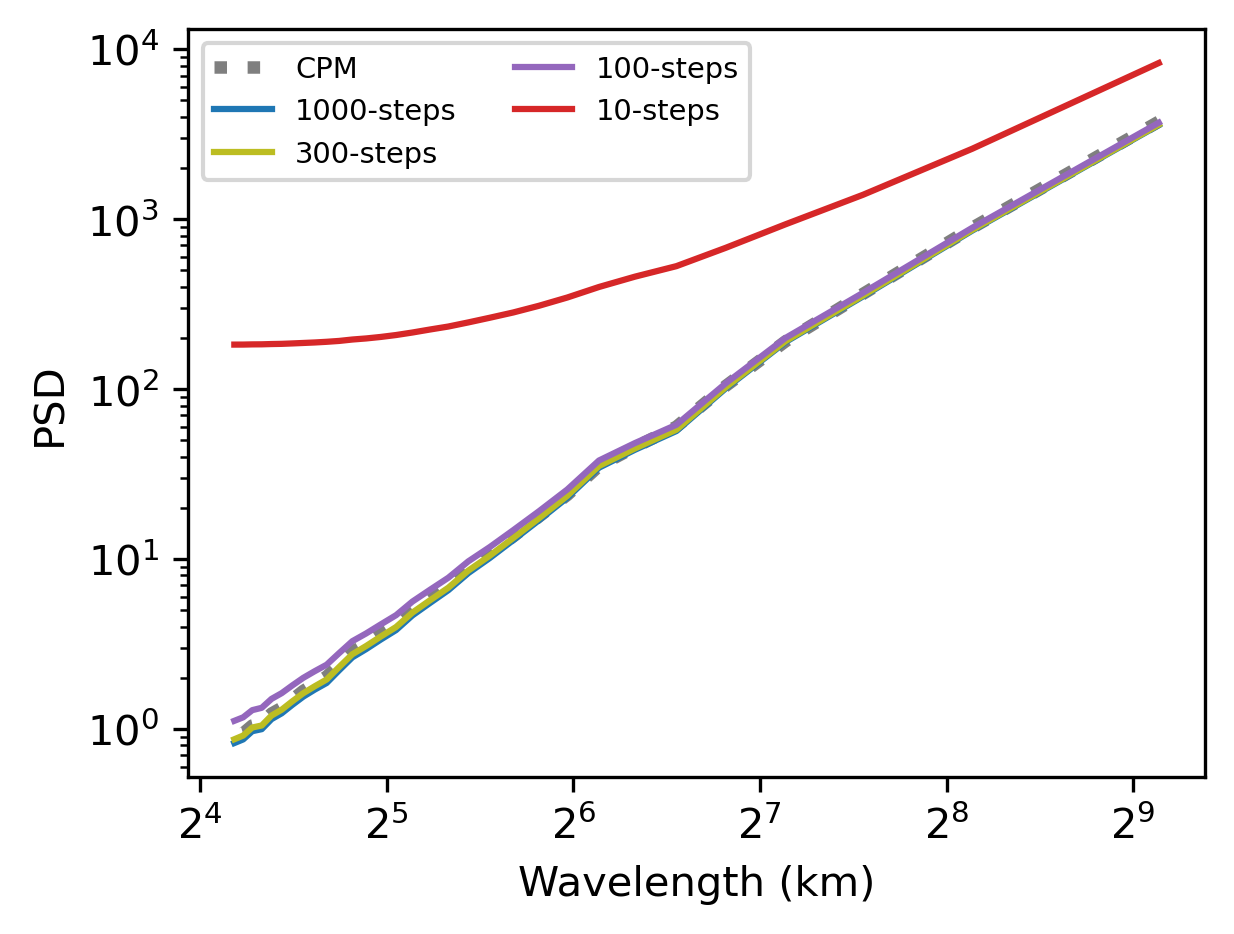

In [ ]:
# if len(eval_vars) > 1:
#     gridspec = np.pad(np.array(eval_vars), (0, -len(eval_vars) % 2), constant_values=".").reshape(-1, 1)
# else:
#     gridspec = np.array([eval_vars])
# structure_fig = plt.figure(figsize=(5.5*gridspec.shape[1], 3.5*gridspec.shape[0]), layout="constrained")
# axd = structure_fig.subplot_mosaic(gridspec, sharey=True, sharex=False)

for var in eval_vars:
    IPython.display.display_markdown(f"### {var}", raw=True)
    # gridspec = np.array([var]).reshape(1,1)
    structure_fig = plt.figure(figsize=(4, 3), layout="constrained")
    axd = structure_fig.subplot_mosaic([[var]], sharey=True, sharex=False)
    cpm_hr_rapsd = pysteps_rapsd(CPM_DAS[var].stack(example=["ensemble_member", "time"]).transpose("example", "grid_latitude", "grid_longitude"), pixel_size=8.8).mean(dim="example").drop_sel(freq=0)
    
    pred_rapsds = [
        {
            "label": model,
            "color": spec["color"],
            "data": pysteps_rapsd(EVAL_DS[source][f"pred_{var}"].sel(model=model).stack(example=["ensemble_member", "sample_id", "time"]).transpose("example", "grid_latitude", "grid_longitude"), pixel_size=8.8).mean(dim="example").drop_sel(freq=0)
        }
        for source, mconfigs in MODELS.items() for model, spec in mconfigs.items()
    ]
    
    ax = axd[var]

    plot_psd(cpm_hr_rapsd, pred_rapsds, ax=ax)
    # ax.set_title(CPM_DAS[var].attrs["long_name"])
    
    plt.show()